# Model comparison and final model selection (Stage 6 + 7)
**Branch:** `feature/model-comparison` - run this **on `main` after all four model branches are merged**. It reads `outputs/results/*.json` written by each model notebook.

It answers: which model is best, by how much, and *why*? The final model is chosen by **tuned cross-validated macro-F1**, never by test score.

In [1]:
import sys; sys.path.append("../src")
import warnings; warnings.filterwarnings("ignore")
from common import *
import shutil

results = {p.stem: json.loads(p.read_text()) for p in RESULTS_DIR.glob("*.json") if p.stem != "dummy_baseline"}
print("Models found:", [r["model"] for r in results.values()])

Models found: ['Decision Tree', 'LightGBM', 'Logistic Regression', 'Random Forest', 'XGBoost']


## 1. The bar to clear - dummy baselines
A model that ignores the features. If a real model is not clearly better, it has learned nothing.

In [2]:
X_train, X_test, y_train, y_test, g_train, cv, class_names = load_and_split()
dummies = dummy_baselines(X_train, y_train, g_train, cv)
dummy_table = pd.DataFrame({k: {"macro-F1": v["cv_macro_f1"], "accuracy": v["cv_accuracy"], "macro-recall": v["cv_macro_recall"]}
                            for k, v in dummies.items()}).T.round(3)
(RESULTS_DIR / "dummy_baseline.json").write_text(json.dumps({k: {m: float(v[m]) for m in ("cv_macro_f1", "cv_accuracy")} for k, v in dummies.items()}, indent=2))
dummy_table

,macro-F1,accuracy,macro-recall
Majority class,0.230,0.528,0.333
Random (class priors),0.335,0.421,0.335


Note how the majority-class dummy gets a decent **accuracy** (~0.53) but a terrible **macro-F1** (~0.23): this is why accuracy is not our main metric.

## 2. Master comparison table (cross-validation on the training set)

In [3]:
rows = []
for r in results.values():
    rows.append({"model": r["model"],
                 "baseline macro-F1": r["baseline"]["cv_macro_f1"],
                 "tuned macro-F1": r["tuned"]["cv_macro_f1"],
                 "std (folds)": r["tuned"]["cv_macro_f1_std"],
                 "tuned - baseline": r["tuned"]["cv_macro_f1"] - r["baseline"]["cv_macro_f1"],
                 "train macro-F1": r["tuned"]["train_macro_f1"],
                 "over-fit gap": r["tuned"]["train_macro_f1"] - r["tuned"]["cv_macro_f1"],
                 "macro-recall": r["tuned"]["cv_macro_recall"],
                 "ROC-AUC (OvR)": r["tuned"]["cv_roc_auc_ovr"],
                 "PR-AUC <30": r["tuned"]["cv_pr_auc_lt30"],
                 "recall <30": r["tuned"]["cv_recall_lt30"],
                 "accuracy": r["tuned"]["cv_accuracy"],
                 "fit s/fold": r["tuned"]["fit_time_s"],
                 "search": f'{r["search"]["method"]} ({r["search"]["search_time_s"]/60:.0f} min)'})
table = pd.DataFrame(rows).set_index("model").sort_values("tuned macro-F1", ascending=False)
table.round(4).to_csv(OUT_DIR / "model_comparison.csv")
table.round(4)

,baseline macro-F1,tuned macro-F1,std (folds),tuned - baseline,train macro-F1,over-fit gap,macro-recall,ROC-AUC (OvR),PR-AUC <30,recall <30,accuracy,fit s/fold,search
model,,,,,,,,,,,,,
LightGBM,0.4514,0.4572,0.0050,0.0058,0.5435,0.0863,0.4783,0.6743,0.2301,0.4082,0.5164,5.8389,random (6 min)
XGBoost,0.4515,0.4556,0.0055,0.0042,0.6616,0.2059,0.4675,0.6692,0.2207,0.3401,0.5240,11.8421,random (7 min)
Random Forest,0.4437,0.4425,0.0068,-0.0011,0.5550,0.1125,0.4571,0.6599,0.2151,0.3499,0.5197,61.1819,random (30 min)
Logistic Regression,0.4239,0.4294,0.0044,0.0054,0.4527,0.0233,0.4544,0.6534,0.2085,0.4102,0.4911,8.4446,grid (2 min)
Decision Tree,0.3851,0.4066,0.0161,0.0214,0.4075,0.0009,0.4405,0.6302,0.1878,0.4111,0.4858,1.2947,grid (1 min)


## 3. Baseline vs tuned, against the dummy baseline

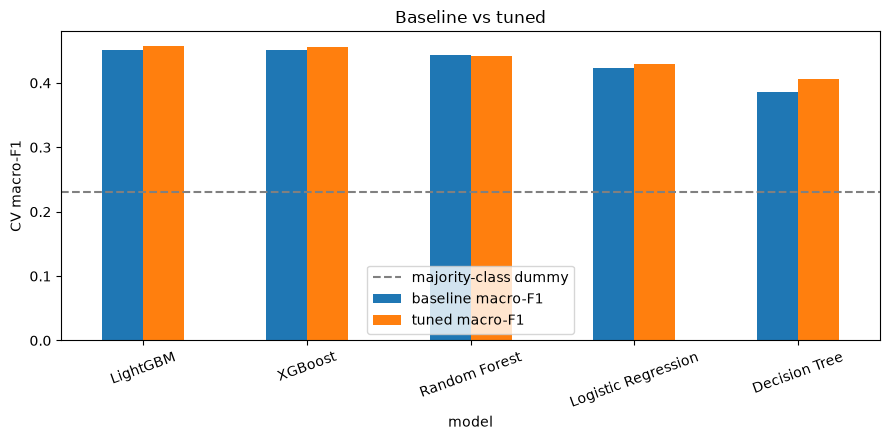

In [4]:
ax = table[["baseline macro-F1", "tuned macro-F1"]].plot(kind="bar", figsize=(9, 4.5), rot=20)
ax.axhline(dummies["Majority class"]["cv_macro_f1"], ls="--", c="grey", label="majority-class dummy")
ax.set_ylabel("CV macro-F1"); ax.set_title("Baseline vs tuned"); ax.legend()
plt.tight_layout(); plt.savefig(FIGS_DIR / "baseline_vs_tuned.png", dpi=150); plt.show()

## 4. Is the difference between models real? (fold-to-fold spread)

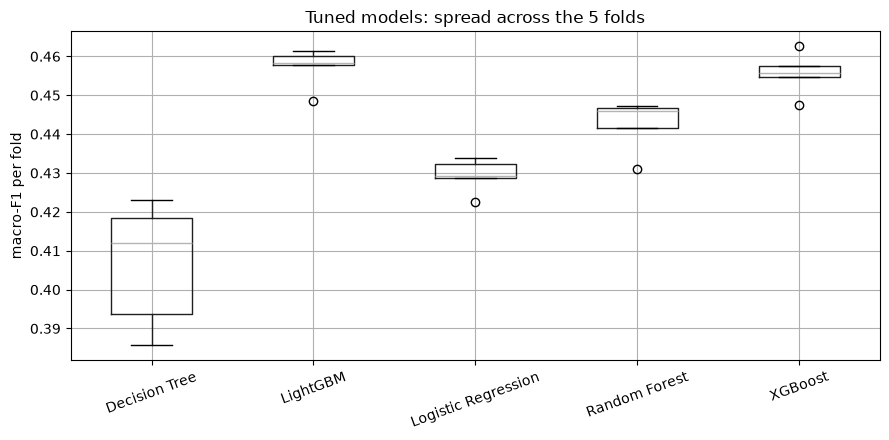

In [5]:
folds = pd.DataFrame({r["model"]: r["tuned"]["cv_macro_f1_folds"] for r in results.values()})
folds.boxplot(figsize=(9, 4.5)); plt.ylabel("macro-F1 per fold"); plt.title("Tuned models: spread across the 5 folds")
plt.xticks(rotation=20); plt.tight_layout(); plt.savefig(FIGS_DIR / "fold_spread.png", dpi=150); plt.show()

If two boxes overlap heavily, the models are statistically similar - then simplicity, speed and interpretability should decide.

## 5. Which classes are hard? (test set, per-class F1 and recall)

In [6]:
per_class = pd.DataFrame({r["model"]: {f"F1 {c}": r["per_class_report"][c]["f1-score"] for c in r["class_names"]} |
                                      {f"recall {c}": r["per_class_report"][c]["recall"] for c in r["class_names"]}
                          for r in results.values()}).T.round(3)
per_class

,F1 <30,F1 >30,F1 NO,recall <30,recall >30,recall NO
Decision Tree,0.251,0.354,0.647,0.343,0.301,0.663
LightGBM,0.276,0.459,0.640,0.413,0.428,0.602
Logistic Regression,0.264,0.400,0.637,0.422,0.347,0.614
Random Forest,0.265,0.403,0.657,0.361,0.347,0.669
XGBoost,0.271,0.467,0.644,0.358,0.448,0.618


## 6. Test-set results (reported, not used for selection)

In [7]:
test_table = pd.DataFrame({r["model"]: r["test"] for r in results.values()}).T[
    ["macro_f1", "macro_recall", "roc_auc_ovr", "pr_auc_lt30", "recall_lt30", "accuracy"]].round(4)
test_table.loc[table.index]

,macro_f1,macro_recall,roc_auc_ovr,pr_auc_lt30,recall_lt30,accuracy
model,,,,,,
LightGBM,0.4581,0.4808,0.6753,0.2339,0.4129,0.5183
XGBoost,0.4606,0.4746,0.6722,0.2286,0.3579,0.5281
Random Forest,0.4420,0.4591,0.6611,0.2182,0.3615,0.5193
Logistic Regression,0.4336,0.4608,0.6543,0.2091,0.4219,0.4967
Decision Tree,0.4174,0.4356,0.6271,0.1797,0.3434,0.4974


## 7. Every experiment in one place (experiment record for the report)

In [8]:
log = pd.concat([pd.read_csv(p) for p in RESULTS_DIR.glob("*_experiments.csv")], ignore_index=True)
log.to_csv(OUT_DIR / "experiment_log_all.csv", index=False)
log[["model", "experiment", "setting", "cv_macro_f1", "train_macro_f1", "cv_macro_recall", "cv_pr_auc_lt30"]].round(4)

,model,experiment,setting,cv_macro_f1,train_macro_f1,cv_macro_recall,cv_pr_auc_lt30
0,Decision Tree,max_depth,max_depth=2,0.3516,0.3557,0.4200,0.1572
1,Decision Tree,max_depth,max_depth=3,0.3782,0.3878,0.4203,0.1695
2,Decision Tree,max_depth,max_depth=5,0.3926,0.4098,0.4307,0.1739
3,Decision Tree,max_depth,max_depth=8,0.3995,0.4496,0.4257,0.1602
4,Decision Tree,max_depth,max_depth=12,0.4034,0.5318,0.4183,0.1453
...,...,...,...,...,...,...,...
67,XGBoost,max_depth,max_depth=8,0.4421,0.7283,0.4473,0.1838
68,XGBoost,Engineered features,with,0.4369,0.5311,0.4550,0.1996
69,XGBoost,Engineered features,without,0.4374,0.5292,0.4561,0.1977
70,XGBoost,Imbalance,balanced weights,0.4369,0.5311,0.4550,0.1996


## 8. Select the final model
**Rule:** highest tuned CV macro-F1. Set `FINAL_MODEL` manually only if the team agrees on a different choice (e.g. two models are within one standard deviation and one is much simpler), and explain it below.

In [9]:
FINAL_MODEL = None   # e.g. "LightGBM" to override
best_name = FINAL_MODEL or table["tuned macro-F1"].idxmax()
best_row = table.loc[best_name]
within = table[table["tuned macro-F1"] >= best_row["tuned macro-F1"] - best_row["std (folds)"]].index.tolist()
print("FINAL MODEL:", best_name)
print("Models within one standard deviation of it:", within)
print(results[slug(best_name)]["search"]["best_params"])

FINAL MODEL: LightGBM
Models within one standard deviation of it: ['LightGBM', 'XGBoost']
{'m__subsample': 0.7, 'm__num_leaves': 63, 'm__n_estimators': 200, 'm__min_child_samples': 50, 'm__learning_rate': 0.03, 'm__colsample_bytree': 0.6}


In [11]:
# Save the final model + everything the backend needs
shutil.copy(MODELS_DIR / f"{slug(best_name)}.joblib", OUT_DIR / "final_model.joblib")
info = {"model": best_name, "classes": class_names,
        "feature_columns": list(X_train.columns),
        "dtypes": {c: str(t) for c, t in X_train.dtypes.items()},
        "best_params": results[slug(best_name)]["search"]["best_params"],
        "cv": {k: v for k, v in results[slug(best_name)]["tuned"].items() if not isinstance(v, list)},
        "test": results[slug(best_name)]["test"]}
(OUT_DIR / "final_model_info.json").write_text(json.dumps(info, indent=2))

# Sanity check: reload the saved file and predict a few test rows exactly as the backend will
loaded = joblib.load(OUT_DIR / "final_model.joblib")
print(pd.DataFrame(loaded.predict_proba(X_test.iloc[:3][info["feature_columns"]]), columns=class_names).round(3))

     <30    >30     NO
0  0.335  0.391  0.274
1  0.312  0.270  0.418
2  0.231  0.246  0.523


## 9. Justification of the final model (fill in as a team)
- **Why this model:**
- **Trade-offs against the runner-up** (accuracy, speed, interpretability, model size):
- **Evidence that it generalises** (train vs CV vs test, fold spread):
- **Which classes it handles well / badly, and why** (see section 5):
- **What the experiments taught us** (regularisation, imbalance handling, feature selection):
- **Limitations and future improvements:**